# Stock Price Data Exploration & Analysis

This notebook explores the preprocessed stock price data and performs exploratory data analysis (EDA).

**Objectives:**
- Load and inspect preprocessed stock data
- Analyze data distributions and statistics
- Visualize price trends and patterns
- Identify data quality issues
- Explore correlations between features

## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

print("✓ Imports successful")

✓ Imports successful


## 2. Load Data

In [2]:
# Load preprocessed data
data_path = project_root / 'data' / 'processed' / 'lstm_ready_data.csv'
print(f"Loading data from: {data_path}")

df = pd.read_csv(data_path)
print(f"\n✓ Loaded {len(df):,} records")
print(f"✓ Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

Loading data from: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\data\processed\lstm_ready_data.csv

✓ Loaded 245 records
✓ Shape: (245, 6)

Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']


In [3]:
# Display first few rows
df.head(10)

,Date,Open,High,Low,Close,Volume
0,2000-01-01,102.8603,43.0436,40.8545,102.8603,18412.0
1,2000-02-01,82.8115,40.9178,38.6529,82.8272,15820.0
2,2000-03-01,71.3604,34.5797,31.3127,71.3756,14061.0
3,2000-04-01,38.9670,33.3769,31.4538,39.3681,7165.0
4,2000-05-01,76.2778,36.8325,33.6328,76.4778,13766.0
5,2000-06-01,77.0374,39.8717,36.8556,77.1925,14435.0
6,2000-07-01,83.7626,34.0783,31.2874,83.1465,16463.0
7,2000-08-01,53.8177,42.3855,40.2926,54.0887,10980.0
8,2000-09-01,54.6230,41.7350,39.7598,54.2077,9920.0
9,2000-10-01,60.6885,44.1257,42.1033,60.7213,11112.0


In [4]:
# Display last few rows
df.tail(10)

,Date,Open,High,Low,Close,Volume
235,2019-08-01,425.8467,123.7610,110.3617,426.5436,122418.0
236,2019-09-01,336.3077,120.8465,109.4367,335.5559,95969.0
237,2019-10-01,538.8160,171.2594,153.8198,539.0278,155240.0
238,2019-11-01,639.7422,177.5990,160.5474,638.8258,183343.0
239,2019-12-01,392.0455,175.9420,162.7811,393.1189,112432.0
240,2020-01-01,348.0321,123.5750,109.3721,346.9286,97140.0
241,2020-02-01,282.1625,160.2657,146.5152,282.7420,80016.0
242,2020-03-01,278.7101,146.8145,129.3931,278.7899,76946.0
243,2020-05-01,496.2151,160.5308,137.1885,495.5412,138256.0
244,2020-06-01,716.9286,160.1446,144.4350,716.9464,200745.0


## 3. Data Quality Check

In [5]:
# Basic info
print("=" * 60)
print("DATA INFORMATION")
print("=" * 60)
df.info()

DATA INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    245 non-null    object 
 1   Open    245 non-null    float64
 2   High    245 non-null    float64
 3   Low     245 non-null    float64
 4   Close   245 non-null    float64
 5   Volume  245 non-null    float64
dtypes: float64(5), object(1)
memory usage: 11.6+ KB


In [6]:
# Check for missing values
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

if missing.sum() == 0:
    print("\n✓ No missing values found!")
else:
    print(f"\n⚠ Total missing values: {missing.sum():,}")


MISSING VALUES
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []

✓ No missing values found!


In [7]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates:,}")
if duplicates > 0:
    print("⚠ Duplicates found!")
else:
    print("✓ No duplicates found!")

Duplicate rows: 0
✓ No duplicates found!


## 4. Statistical Summary

In [8]:
# Statistical summary
print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
df.describe()

STATISTICAL SUMMARY


,Open,High,Low,Close,Volume
count,245.0000,245.0000,245.0000,245.0000,245.0000
mean,394.7045,137.2140,115.2639,394.6996,104994.1347
std,360.0892,65.6742,51.3332,360.2360,98556.8195
min,23.7240,30.1195,28.6922,23.4427,4501.0000
25%,190.0515,83.9830,69.0530,188.7904,50758.0000
50%,302.0091,138.0157,116.6938,302.0263,81432.0000
75%,442.6681,177.5990,151.4934,445.9744,119516.0000
max,2372.5249,326.8538,222.1233,2366.8582,617750.0000


In [9]:
# Date range analysis (if Date column exists)
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    print(f"\nDate Range:")
    print(f"  Start: {df['Date'].min()}")
    print(f"  End: {df['Date'].max()}")
    print(f"  Duration: {(df['Date'].max() - df['Date'].min()).days} days")


Date Range:
  Start: 2000-01-01 00:00:00
  End: 2020-06-01 00:00:00
  Duration: 7457 days


## 5. Data Visualizations

### 5.1 Price Trends Over Time

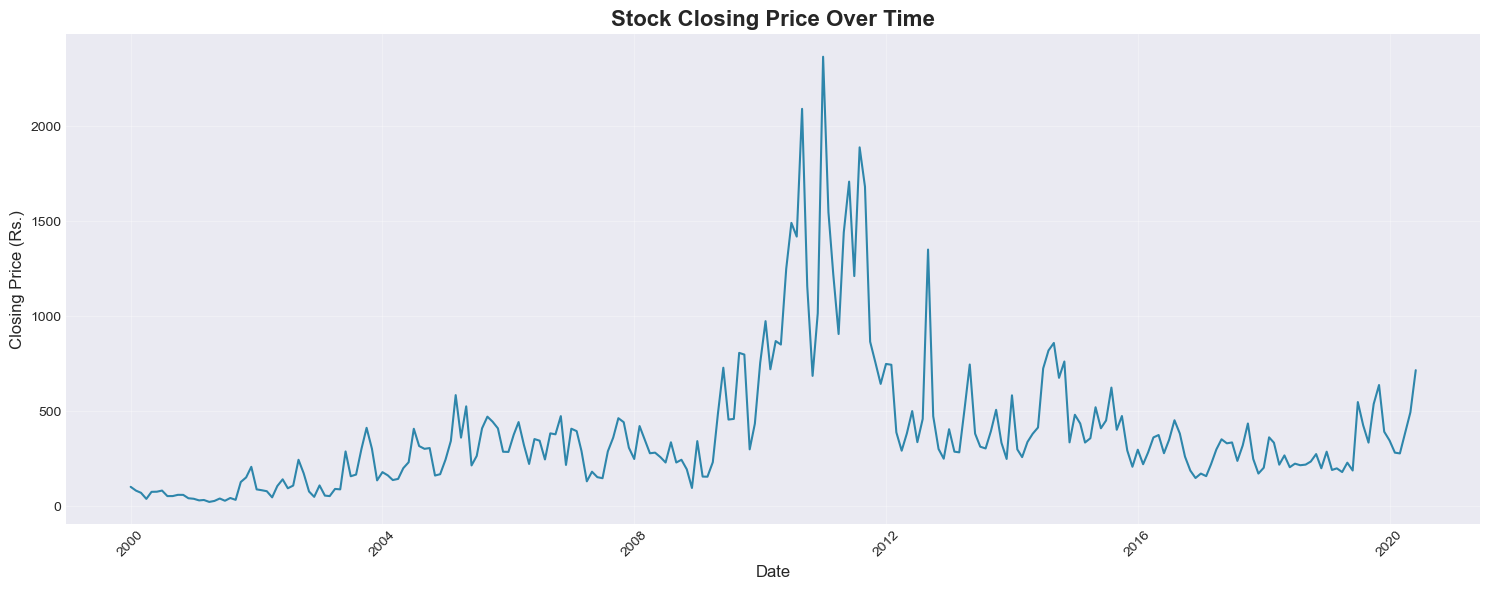

In [10]:
# Plot closing price over time
if 'Date' in df.columns and 'Close' in df.columns:
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(df['Date'], df['Close'], linewidth=1.5, color='#2E86AB')
    ax.set_title('Stock Closing Price Over Time', fontsize=16, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Closing Price (Rs.)', fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Date or Close column not found")

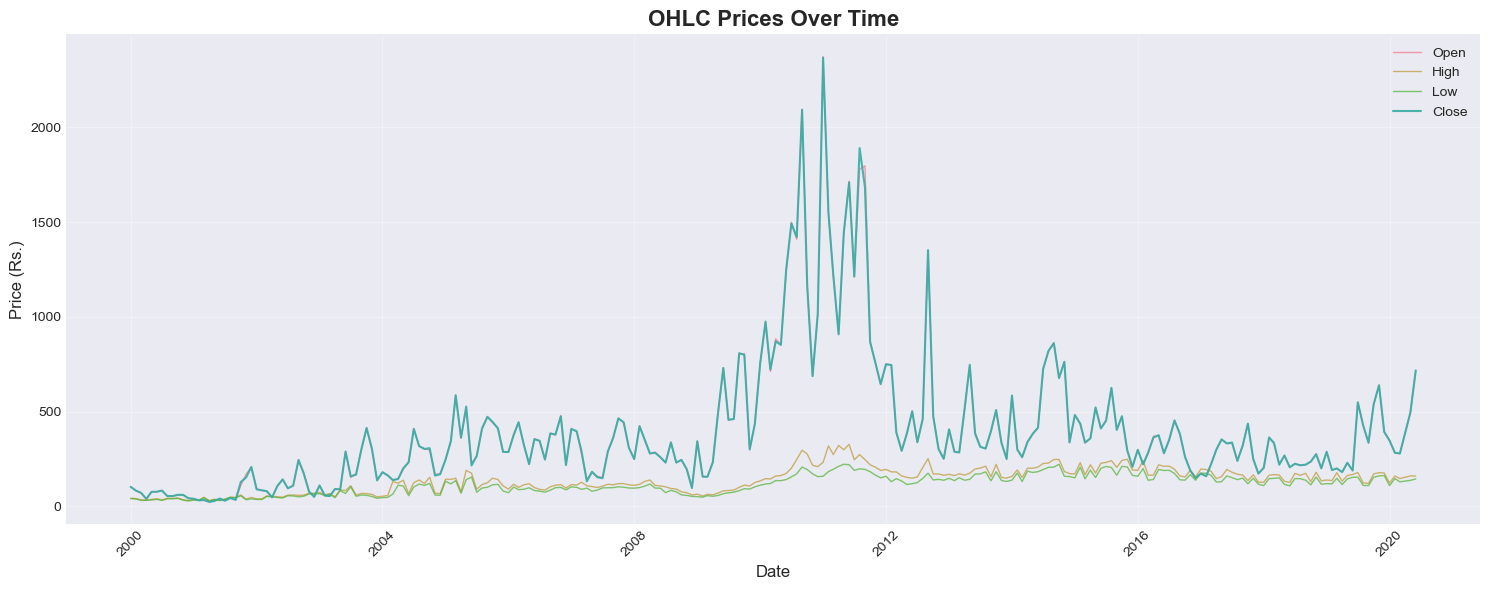

In [11]:
# Plot OHLC prices
if all(col in df.columns for col in ['Date', 'Open', 'High', 'Low', 'Close']):
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(df['Date'], df['Open'], label='Open', alpha=0.7, linewidth=1)
    ax.plot(df['Date'], df['High'], label='High', alpha=0.7, linewidth=1)
    ax.plot(df['Date'], df['Low'], label='Low', alpha=0.7, linewidth=1)
    ax.plot(df['Date'], df['Close'], label='Close', alpha=0.9, linewidth=1.5)
    ax.set_title('OHLC Prices Over Time', fontsize=16, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Price (Rs.)', fontsize=12)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 5.2 Volume Analysis

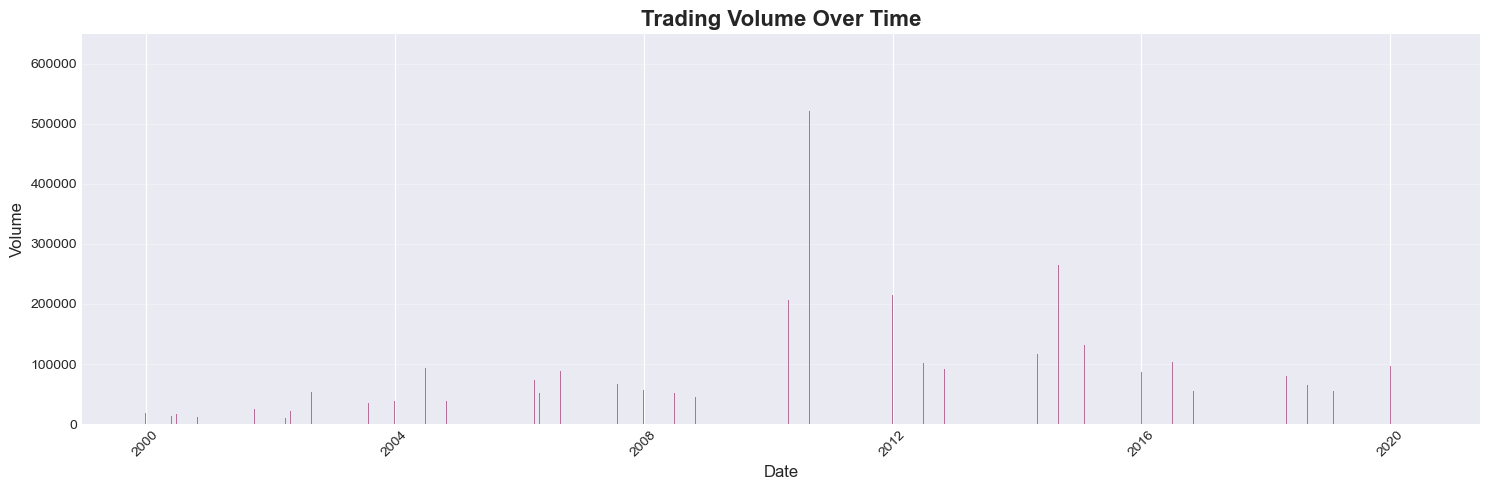

In [12]:
# Plot trading volume
if 'Date' in df.columns and 'Volume' in df.columns:
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.bar(df['Date'], df['Volume'], color='#A23B72', alpha=0.7, width=0.8)
    ax.set_title('Trading Volume Over Time', fontsize=16, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Volume', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 5.3 Price Distribution

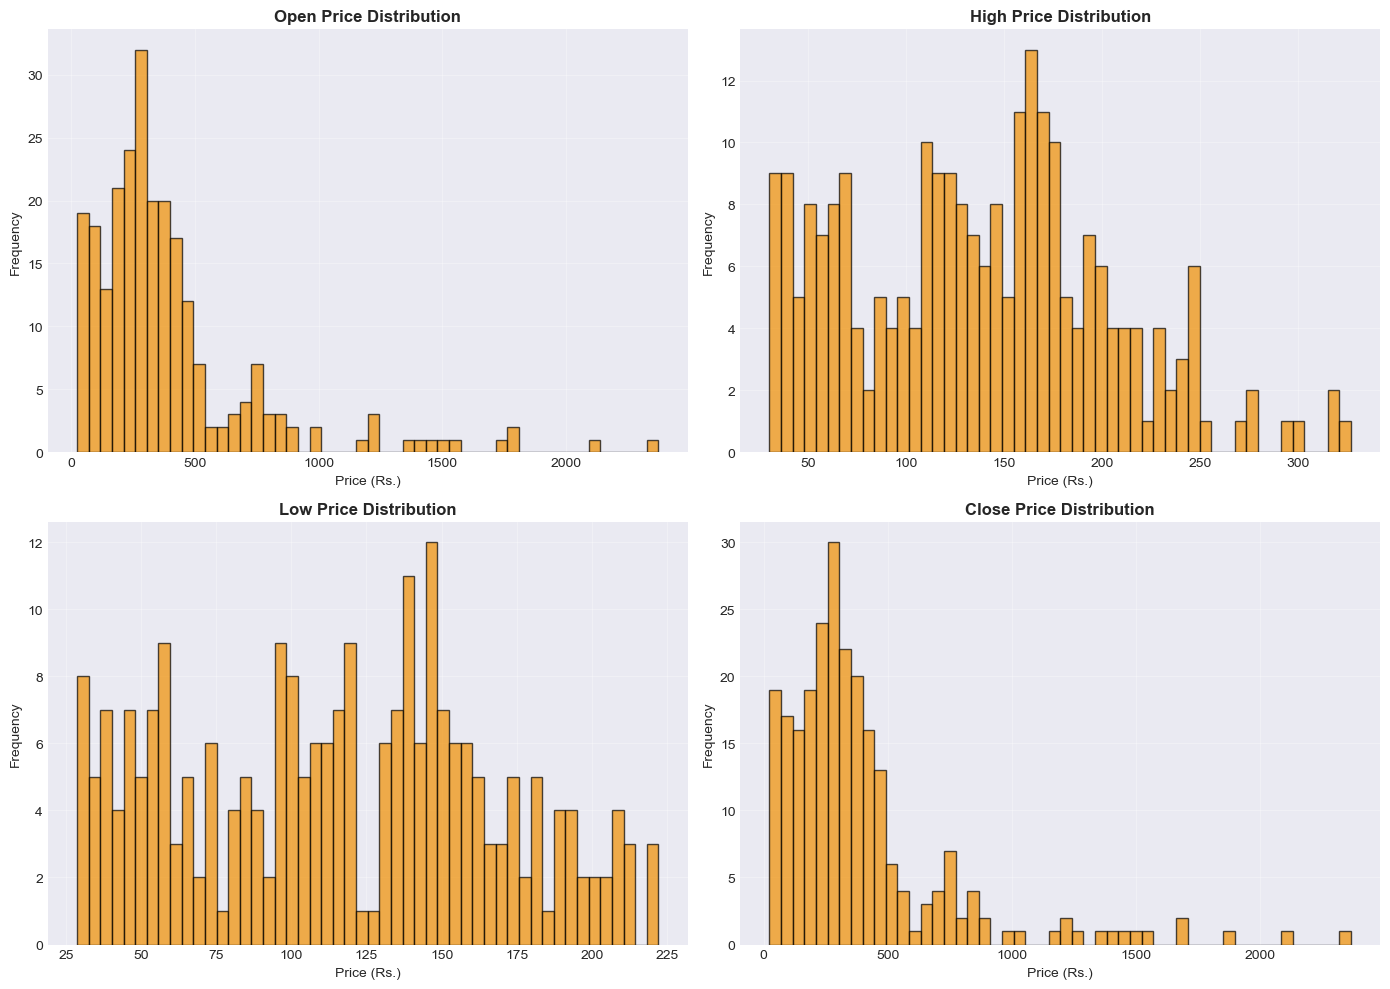

In [13]:
# Distribution plots for price features
price_cols = [col for col in ['Open', 'High', 'Low', 'Close'] if col in df.columns]

if price_cols:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    
    for idx, col in enumerate(price_cols):
        axes[idx].hist(df[col], bins=50, color='#F18F01', alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'{col} Price Distribution', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Price (Rs.)', fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### 5.4 Correlation Analysis

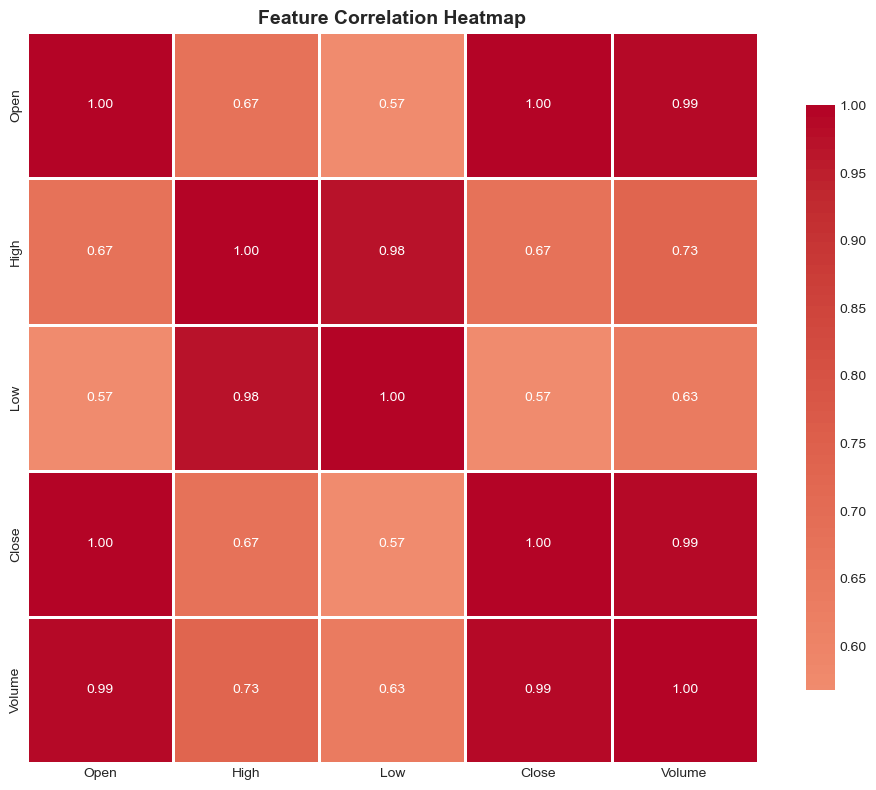


Highest correlations with Close price:
Close     1.0000
Open      0.9996
Volume    0.9906
High      0.6731
Low       0.5678
Name: Close, dtype: float64


In [14]:
# Correlation matrix
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 1:
    correlation = df[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, 
                cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\nHighest correlations with Close price:")
    if 'Close' in correlation.columns:
        close_corr = correlation['Close'].sort_values(ascending=False)
        print(close_corr)

### 5.5 Price Changes and Returns

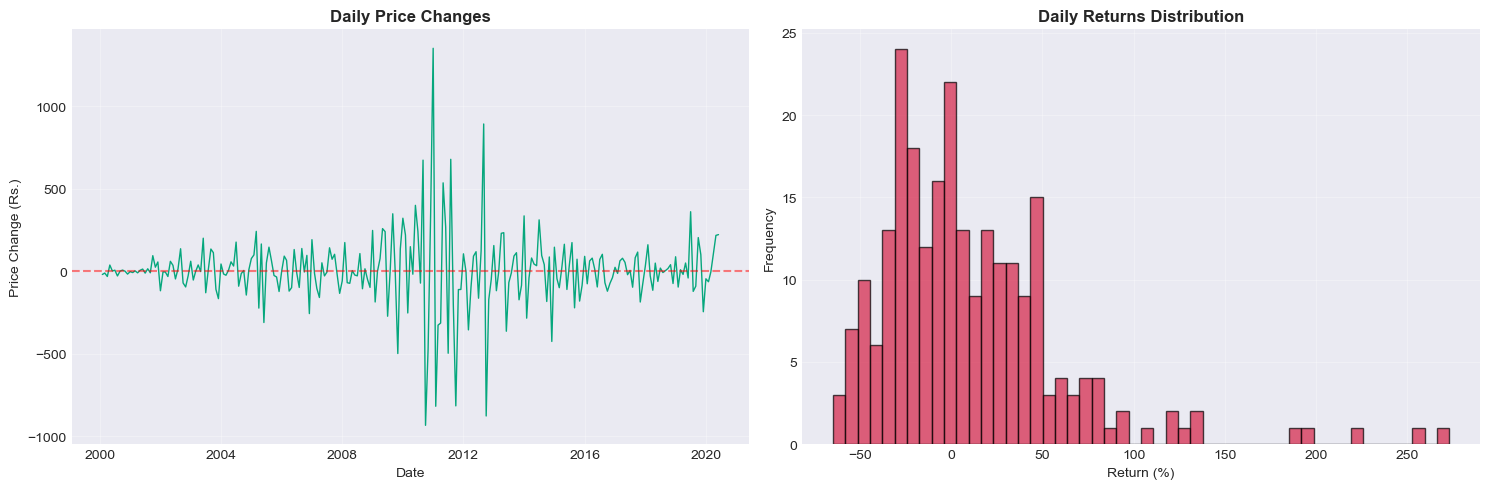


Return Statistics:
  Mean Daily Return: 10.1212%
  Std Daily Return: 50.7663%
  Min Daily Return: -64.8839%
  Max Daily Return: 273.1524%


In [15]:
# Calculate daily returns
if 'Close' in df.columns:
    df['Daily_Return'] = df['Close'].pct_change() * 100
    df['Price_Change'] = df['Close'].diff()
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Price changes
    axes[0].plot(df['Date'] if 'Date' in df.columns else range(len(df)), 
                 df['Price_Change'], linewidth=1, color='#06A77D')
    axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes[0].set_title('Daily Price Changes', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Date' if 'Date' in df.columns else 'Index')
    axes[0].set_ylabel('Price Change (Rs.)')
    axes[0].grid(True, alpha=0.3)
    
    # Returns distribution
    axes[1].hist(df['Daily_Return'].dropna(), bins=50, color='#D62246', alpha=0.7, edgecolor='black')
    axes[1].set_title('Daily Returns Distribution', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Return (%)')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nReturn Statistics:")
    print(f"  Mean Daily Return: {df['Daily_Return'].mean():.4f}%")
    print(f"  Std Daily Return: {df['Daily_Return'].std():.4f}%")
    print(f"  Min Daily Return: {df['Daily_Return'].min():.4f}%")
    print(f"  Max Daily Return: {df['Daily_Return'].max():.4f}%")

### 5.6 Moving Averages

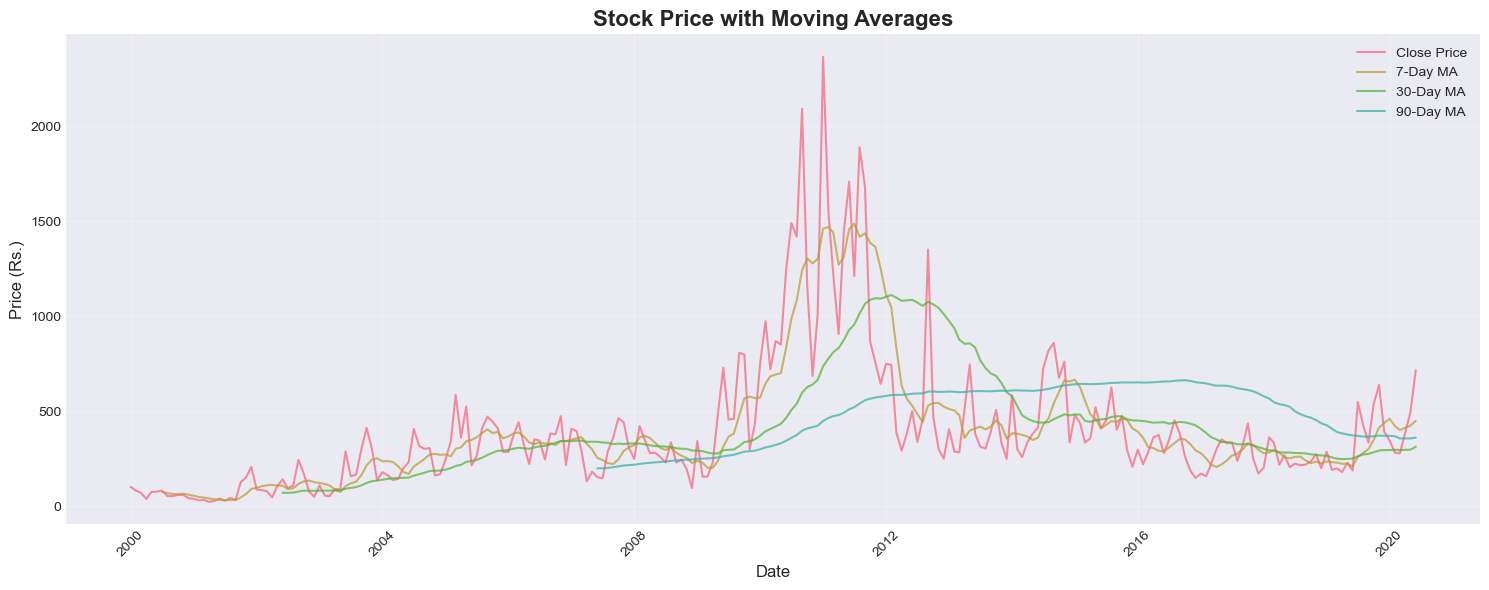

In [16]:
# Calculate moving averages
if 'Close' in df.columns:
    df['MA_7'] = df['Close'].rolling(window=7).mean()
    df['MA_30'] = df['Close'].rolling(window=30).mean()
    df['MA_90'] = df['Close'].rolling(window=90).mean()
    
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(df['Date'] if 'Date' in df.columns else range(len(df)), 
            df['Close'], label='Close Price', linewidth=1.5, alpha=0.8)
    ax.plot(df['Date'] if 'Date' in df.columns else range(len(df)), 
            df['MA_7'], label='7-Day MA', linewidth=1.5, alpha=0.7)
    ax.plot(df['Date'] if 'Date' in df.columns else range(len(df)), 
            df['MA_30'], label='30-Day MA', linewidth=1.5, alpha=0.7)
    ax.plot(df['Date'] if 'Date' in df.columns else range(len(df)), 
            df['MA_90'], label='90-Day MA', linewidth=1.5, alpha=0.7)
    
    ax.set_title('Stock Price with Moving Averages', fontsize=16, fontweight='bold')
    ax.set_xlabel('Date' if 'Date' in df.columns else 'Index', fontsize=12)
    ax.set_ylabel('Price (Rs.)', fontsize=12)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    if 'Date' in df.columns:
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 6. Summary and Insights

In [17]:
# Summary statistics
print("=" * 70)
print("DATA EXPLORATION SUMMARY")
print("=" * 70)
print(f"\n📊 Dataset Overview:")
print(f"  - Total Records: {len(df):,}")
print(f"  - Total Features: {len(df.columns)}")
print(f"  - Missing Values: {df.isnull().sum().sum():,}")
print(f"  - Duplicate Records: {df.duplicated().sum():,}")

if 'Close' in df.columns:
    print(f"\n💰 Price Statistics:")
    print(f"  - Mean Price: Rs. {df['Close'].mean():.2f}")
    print(f"  - Median Price: Rs. {df['Close'].median():.2f}")
    print(f"  - Min Price: Rs. {df['Close'].min():.2f}")
    print(f"  - Max Price: Rs. {df['Close'].max():.2f}")
    print(f"  - Price Range: Rs. {df['Close'].max() - df['Close'].min():.2f}")
    print(f"  - Standard Deviation: Rs. {df['Close'].std():.2f}")

if 'Volume' in df.columns:
    print(f"\n📈 Trading Volume:")
    print(f"  - Mean Volume: {df['Volume'].mean():,.0f}")
    print(f"  - Median Volume: {df['Volume'].median():,.0f}")
    print(f"  - Max Volume: {df['Volume'].max():,.0f}")

print("\n✓ Data exploration completed successfully!")

DATA EXPLORATION SUMMARY

📊 Dataset Overview:
  - Total Records: 245
  - Total Features: 11
  - Missing Values: 126
  - Duplicate Records: 0

💰 Price Statistics:
  - Mean Price: Rs. 394.70
  - Median Price: Rs. 302.03
  - Min Price: Rs. 23.44
  - Max Price: Rs. 2366.86
  - Price Range: Rs. 2343.42
  - Standard Deviation: Rs. 360.24

📈 Trading Volume:
  - Mean Volume: 104,994
  - Median Volume: 81,432
  - Max Volume: 617,750

✓ Data exploration completed successfully!


## 7. Next Steps

Based on this exploration, proceed to:
1. **Notebook 02**: Model Training - Train LSTM models on this data
2. **Notebook 03**: Model Evaluation - Evaluate model performance
3. **Notebook 04**: Model Validation - Validate predictions
4. **Notebook 05**: Ensemble Analysis - Compare multiple models